In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
import matplotlib.pyplot as mt

In [3]:
cd = pd.read_csv("autism_detection_15000.csv")

In [4]:
cd.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,0,1,1,0,1,0,0,1,0,0,...,m,White-European,no,no,Belgium,no,4,'18 and more',Self,NO
1,1,1,1,1,1,0,1,1,0,1,...,m,White-European,no,no,Ireland,no,8,'18 and more',Self,YES
2,0,1,0,0,0,0,0,1,0,0,...,f,'South Asian',no,no,India,no,2,'18 and more',Self,NO
3,1,0,0,1,0,0,0,1,0,1,...,m,'Middle Eastern ',no,no,'United Arab Emirates',no,4,'18 and more',Parent,NO
4,1,1,0,1,1,1,1,1,0,1,...,f,'Middle Eastern ',no,no,'United Arab Emirates',no,8,'18 and more',Self,YES


In [5]:
cd.tail()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
14995,1,1,0,1,0,0,0,0,0,1,...,f,White-European,no,no,'United Kingdom',no,4,'18 and more',Self,NO
14996,1,1,1,1,1,1,0,1,1,1,...,m,White-European,no,no,'United Kingdom',no,9,'18 and more',Self,YES
14997,1,1,0,1,1,0,1,1,0,1,...,f,White-European,no,no,'United States',no,7,'18 and more',Self,YES
14998,0,1,1,1,0,0,0,0,0,1,...,f,White-European,yes,no,'United States',no,4,'18 and more',Self,NO
14999,1,1,1,1,1,1,1,1,1,1,...,f,White-European,no,no,Romania,no,10,'18 and more',Self,YES


In [6]:
cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         15000 non-null  int64 
 1   A2_Score         15000 non-null  int64 
 2   A3_Score         15000 non-null  int64 
 3   A4_Score         15000 non-null  int64 
 4   A5_Score         15000 non-null  int64 
 5   A6_Score         15000 non-null  int64 
 6   A7_Score         15000 non-null  int64 
 7   A8_Score         15000 non-null  int64 
 8   A9_Score         15000 non-null  int64 
 9   A10_Score        15000 non-null  int64 
 10  age              15000 non-null  object
 11  gender           15000 non-null  object
 12  ethnicity        15000 non-null  object
 13  jundice          15000 non-null  object
 14  austim           15000 non-null  object
 15  contry_of_res    15000 non-null  object
 16  used_app_before  15000 non-null  object
 17  result           15000 non-null

In [7]:
cd.replace('?', pd.NA, inplace=True)

In [8]:
cd.isnull().sum()

A1_Score              0
A2_Score              0
A3_Score              0
A4_Score              0
A5_Score              0
A6_Score              0
A7_Score              0
A8_Score              0
A9_Score              0
A10_Score             0
age                  43
gender                0
ethnicity          1963
jundice               0
austim                0
contry_of_res         0
used_app_before       0
result                0
age_desc              0
relation           1963
Class/ASD             0
dtype: int64

In [9]:
cd.fillna(cd.mode().iloc[0], inplace=True)

In [10]:
cd.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [12]:
cd.replace({
    'gender': {'m': 0, 'f': 1},
    'jundice': {'no': 0, 'yes': 1},
    'austim': {'no': 0, 'yes': 1},
    'used_app_before': {'no': 0, 'yes': 1},
    'Class/ASD': {'NO': 0, 'YES': 1}
}, inplace=True)

cd = cd.infer_objects(copy=False)

In [15]:
cd.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,0,1,1,0,1,0,0,1,0,0,...,0,9,0,0,23,0,4,0,4,0
1,1,1,1,1,1,0,1,1,0,1,...,0,9,0,0,42,0,8,0,4,1
2,0,1,0,0,0,0,0,1,0,0,...,1,1,0,0,38,0,2,0,4,0
3,1,0,0,1,0,0,0,1,0,1,...,0,0,0,0,8,0,4,0,2,0
4,1,1,0,1,1,1,1,1,0,1,...,1,0,0,0,8,0,8,0,4,1


In [13]:
le = LabelEncoder()
cd['ethnicity'] = le.fit_transform(cd['ethnicity'])
cd['contry_of_res'] = le.fit_transform(cd['contry_of_res'])
cd['age_desc'] = le.fit_transform(cd['age_desc'])
cd['relation'] = le.fit_transform(cd['relation'])


In [14]:
cd.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,0,1,1,0,1,0,0,1,0,0,...,0,9,0,0,23,0,4,0,4,0
1,1,1,1,1,1,0,1,1,0,1,...,0,9,0,0,42,0,8,0,4,1
2,0,1,0,0,0,0,0,1,0,0,...,1,1,0,0,38,0,2,0,4,0
3,1,0,0,1,0,0,0,1,0,1,...,0,0,0,0,8,0,4,0,2,0
4,1,1,0,1,1,1,1,1,0,1,...,1,0,0,0,8,0,8,0,4,1


In [17]:
X = cd[['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
        'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']]

y = cd['Class/ASD']

In [18]:
cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         15000 non-null  int64 
 1   A2_Score         15000 non-null  int64 
 2   A3_Score         15000 non-null  int64 
 3   A4_Score         15000 non-null  int64 
 4   A5_Score         15000 non-null  int64 
 5   A6_Score         15000 non-null  int64 
 6   A7_Score         15000 non-null  int64 
 7   A8_Score         15000 non-null  int64 
 8   A9_Score         15000 non-null  int64 
 9   A10_Score        15000 non-null  int64 
 10  age              15000 non-null  object
 11  gender           15000 non-null  int64 
 12  ethnicity        15000 non-null  int64 
 13  jundice          15000 non-null  int64 
 14  austim           15000 non-null  int64 
 15  contry_of_res    15000 non-null  int64 
 16  used_app_before  15000 non-null  int64 
 17  result           15000 non-null

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, test_size=0.1
)


In [20]:
model1 = DecisionTreeClassifier(
    criterion='gini',     
    max_depth=5
)


In [21]:
model1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [22]:
trainpd=model1.predict(X_train)
check1=metrics.r2_score(y_train,trainpd)
print(check1)

0.7610183291443419


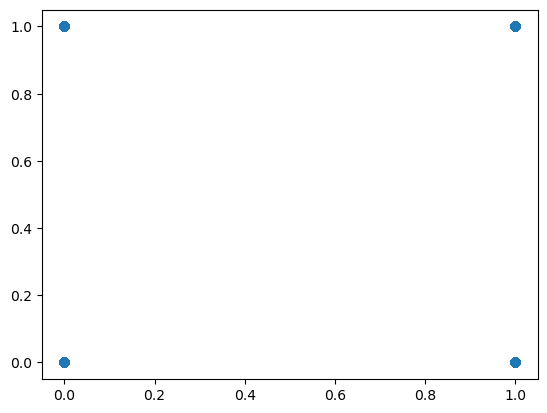

In [23]:
mt.scatter(y_train,trainpd)
mt.show()

In [24]:
model1.fit(X_test,y_test)

DecisionTreeClassifier(max_depth=5)

In [25]:
testpd=model1.predict(X_test)
check2=metrics.r2_score(y_test,testpd)
print(check2)

0.7628730167821753


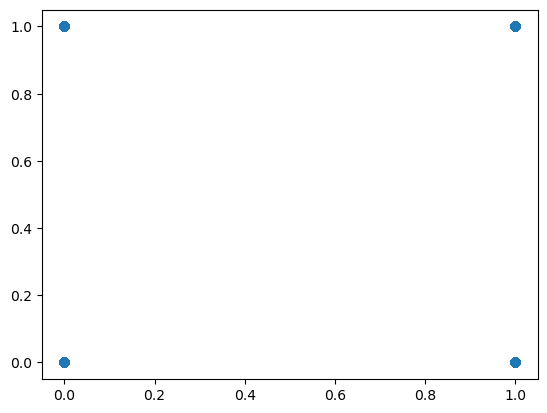

In [26]:
mt.scatter(y_train,trainpd)
mt.show()

In [27]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model1, f)
